In [1]:
# # Decision Tree Classifier

# ## What is Decision Tree?

# Decision Tree is a Supervised Machine Learning algorithm used for both Classification and Regression.

# It makes decisions by asking a sequence of questions and finally reaches a prediction.

# It looks like an upside-down tree.

# ## Real World Examples

# - Loan Approval
# - Disease Diagnosis
# - Customer Churn Prediction
# - Fraud Detection
# - Employee Selection

# ## What You Will Learn

# - Decision Tree
# - Gini Index
# - Entropy
# - Model Training
# - Prediction
# - Accuracy
# - Feature Importance

Code Cell 1 Load the Iris dataset.

In [2]:
from sklearn.datasets import load_iris
iris= load_iris()
X=iris.data
y=iris.target
print(X.shape)
print(y.shape)

(150, 4)
(150,)


Code Cell 2 Split the dataset.

In [5]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state=42
)

In [6]:
# # Why No Feature Scaling?

# Unlike KNN, Decision Tree does not calculate distances.

# It splits data based on conditions like:

# Petal Length <= 2.45

# Therefore, feature scaling is generally **not required**.

Code Cell 3   Create the Decision Tree model.

In [7]:
# Now we need the algorithm that will learn decision rules.

from sklearn.tree import DecisionTreeClassifier
model =DecisionTreeClassifier(
    random_state=42
)

Code Cell 4 **(Very Imp.)**
Train the Model

In [8]:
# Now the model learns how to classify flowers.
model.fit(
    X_train,
    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

Code Cell 5
 Predict Classes

In [17]:
predictions = model.predict(
    X_test
)

predictions[:10]

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1])

Code Cell 6
 Compare Actual vs Predicted

In [18]:
print(len(X))
print(len(X_test))
print(len(y_test))
print(len(predictions))

150
30
30
30


In [19]:
import pandas as pd

comparison = pd.DataFrame({

    "Actual": y_test,

    "Predicted": predictions

})

comparison.head(10)

,Actual,Predicted
0,1,1
1,0,0
2,2,2
3,1,1
4,1,1
5,0,0
6,1,1
7,2,2
8,1,1
9,1,1


Code Cell 7
 Calculate Accuracy

In [20]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,predictions
)
print("Accuracy : ",accuracy)

Accuracy :  1.0


Code Cell 8
Confusion Matrix

In [23]:
from sklearn.metrics import  confusion_matrix
cm = confusion_matrix(
    y_test,
    predictions
)
print("confusion_matrix\n",cm)

confusion_matrix
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


Code Cell 9
 Classification Report

In [24]:
from sklearn.metrics import classification_report
print(
    classification_report(
        y_test,predictions
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



Code Cell 10  Feature Importance

In [ ]:
# Decision Tree can tell us which features were most useful for making decisions.

importance = pd.DataFrame({
    "feature":iris.feature_names,
    "Importance":model.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False # large -> Small
)

,feature,Importance
2,petal length (cm),0.906143
3,petal width (cm),0.077186
1,sepal width (cm),0.016670
0,sepal length (cm),0.000000


In [ ]:
# Higher importance means that feature contributed more to the classification.
# Example:
# Petal Length
# ↓
# Most Important

Code Cell 11  Visualize the Decision Tree

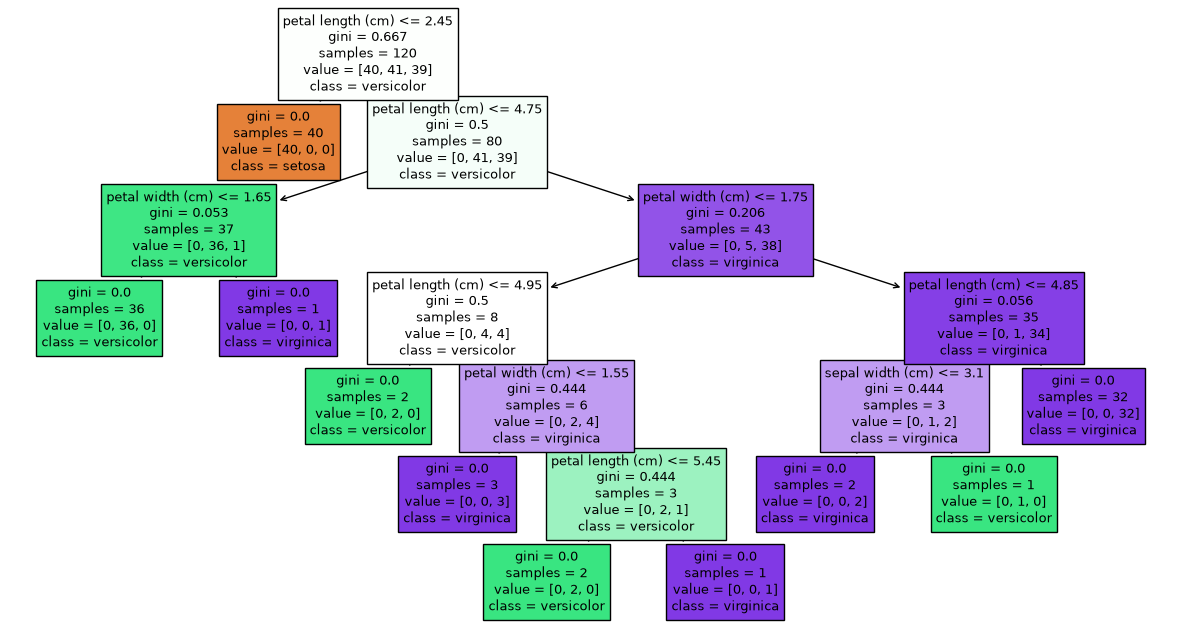

In [26]:
# A Decision Tree becomes much easier to understand when we can see its structure.

from sklearn.tree import plot_tree

import matplotlib.pyplot as plt

plt.figure(figsize=(15,8))

plot_tree(

    model,

    feature_names=iris.feature_names,

    class_names=iris.target_names,

    filled=True

)

plt.show()

In [27]:
# Each box in the tree represents a decision.
# Example:

# Petal Length <= 2.45 ?
#         Yes
#          ↓
#       Setosa
#         No
#          ↓
# Another Question

# The model continues asking questions until it reaches a final prediction.

In [ ]:
# # How Decision Tree Works?

# Start
# ↓
# Ask the Best Question
# ↓
# Split the Dataset
# ↓
# Repeat the Process
# ↓
# Leaf Node
# ↓
# Prediction

In [28]:
# Real-World Example
# Imagine a bank deciding whether to approve a loan.

# Income > 50,000 ?
#         Yes
# Credit Score > 700 ?
#         Yes
# Loan Approved
#         No
# Loan Rejected

# This sequence of questions is exactly how a Decision Tree works.